# spatsoc paper 2

Alec L. Robitaille [](https://orcid.org/0000-0002-4706-1762) (Memorial University of Newfoundland and Labrador)  
Quinn M. R. Webber [](https://orcid.org/0000-0002-0434-9360) (University of Guelph)  
Eric Vander Wal [](https://orcid.org/0000-0002-8534-4317) (Memorial University of Newfoundland and Labrador)  
January 14, 2026

1.  Beyond social networks, dyadic measures
2.  Extending social networks derived from GPS using detailed dyadic measures beyond rates of association
3.  Linking social processes to spatial/geography environment, hint at selection
4.  Expanding spatsoc to version N by including important and unavailable methods in R

# Introduction

In [ ]:
targets::tar_source('R')

qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103


Attaching package: 'janitor'

The following objects are masked from 'package:stats':

    chisq.test, fisher.test

Linking to GEOS 3.14.1, GDAL 3.12.0, PROJ 9.7.0; sf_use_s2() is TRUE

udunits database from /usr/share/udunits/udunits2.xml

Animal social dynamics have broad implications in ecology including resource availability, disease transmission and collective behaviour. Social network analysis can measure the structure of social systems, the consequences of an individual’s position in a network, the spread of disease or information across networks, and the influence of the environment \[@Farine_2015\]. Open source tools have been developed to derive social networks from animal telemetry data \[@Robitaille_2019\] using aggregated association rates or home range overlap. The methods have been used to measure contact rates to measure social cohesion \[@Bracken_2022\], human-wildlife conflict \[@Boudreau_2022\], socioecology and resource availability \[@Peignier_2019\], community structure \[@Sunga_2021\], influence of stress of social proximity \[@Keshavarzi_2023\], social patterns in non-social species \[@Heeres_2024\].

Many facets of group living need to be measured to better understand animal social systems \[@King_2018\]. There are additional types of dyadic relationships including genetic, affiliative, agonistic, and cooperative \[@Farine_2015\]. There are also interactions between spatial and social phenotypes and environments \[@Webber_2023\]. Using direct observations, researchers have studied intragroup social dynamics including social foraging \[@Barnard_1981; @Giraldeau_1986; @Hirsch_2020\], spatial position within groups \[@Krause_1994; @Monus_2008\] and the influence of individual traits such as age, sex and dominance \[@Furuichi_1983; @King_2009; @Teichroeb_2015\]. Unfortunately, direct observations can be labor-intensive to collect and susceptible to observer bias \[@Smith_2021\], with low spatial and temporal resolution making them imperfect for studies of collective movement \[@King_2018\].

There are expanded opportunities to understand animal social systems by pairing advances in remote tracking technology with emerging approaches to measuring intragroup social dynamics. The availability and resolution of remote tracking data continues to improve \[@Kays_2015; @Kays_2022; @Nathan_2022\]. There are over two decades of research on measuring the interaction between moving individuals from the study of “moving point objects” in GISciences \[@Andersson_2008; @Dodge_2008; @Laube_2005\] to group coordination of moving groups \[@Couzin_2002; @Herbert-Read_2011\] and leadership and decision making \[@King_2011; @Nagy_2010; @Strandburg-Peshkin_2015\]. Despite this, we suggest the availability of open source tools \[@Hampton_2015; @Powers_2019; @Wilson_2017\] is the missing piece between the call to integrate technology enhanced research with multidisciplinary approaches to better understand animal social systems \[@Couzin_2023; @King_2018\].

Here we present 18 new functions for the R package {spatsoc} \[@Robitaille_2019\] for measuring intragroup dynamics. We conducted a scoping review to identify metrics applicable to spatiotemporal data used in ecological studies focused on dyadic interactions, dominance hierarchies and leadership patterns (Sup A, B). Of the resulting metrics, we selected those with a high number of citations (as a measure of value for the target audience) and unavailability in the R programming language, either through R packages or supplemental materials in the literature. We will demonstrate these new functions through a case study and discuss biological interpretation.

# Methods

We conducted a scoping review to identify metrics used in ecology studies for measuring dyadic interactions, dominance hierarchies and leadership patterns. We focused on metrics applicable to spatiotemporal data such as GPS telemetry. See details in Supplement A: Scoping Review Methods.

Metrics were selected for inclusion in {spatsoc} based on their relative importance as measured by frequency of use in the review, as well as their lack of availability in R packages when the review was conducted. Some metrics were specifically not chosen for inclusion such as metrics relating to posture, static interaction or home range overlap and metrics based on statistical models such as Hidden Markov model and Granger causality. A full list of metrics not selected is in Supplement C: Selected Metrics.

# Case study

Functionality previously available in {spatsoc} includes spatiotemporal grouping, distance based edge-list generation and data-stream permutations (Robitaille et al. 2019). These functions have allowed users to detect interactions between individuals, measure coocurrence within and across species, and generate social networks from telemetry data. <!-- (TODO: cite examples citing spatsoc) -->

Spatiotemporal grouping can be performed given a telemetry dataset, temporal and spatial thresholds, and one of three grouping functions: `group_pts`, `group_lines` or `group_polys`. These return a unique identifier for each spatiotemporal group defined using point based distances, linear trajectory overlap and home range overlap, respectively.

For example, the suggested `group_pts` workflow with example data from the package:

In [ ]:
# Load packages
library(data.table)
library(spatsoc)

# Read example data
DT <- fread(system.file("extdata", "DT.csv", package = "spatsoc"))

# Cast the character column to POSIXct
DT[, datetime := as.POSIXct(datetime, tz = 'UTC')]

# Set variables
temporal_threshold  <- '20 minutes'
spatial_threshold <- 50
id <- 'ID'
coords <- c('X', 'Y')
utm <- 32736

# Setup DT for geometry interface
get_geometry(DT, coords = coords, crs = utm)

# Temporal grouping
group_times(DT, datetime = 'datetime', threshold = temporal_threshold)

# Spatial grouping with timegroup
group_pts(DT, threshold = spatial_threshold, id = id,
          coords = coords, timegroup = 'timegroup')

In [ ]:
DT <- tar_read(spatial_groups)
tinytable::tt(DT[order(timegroup)][1:5])

ID,X,Y,datetime,population,geometry,doy,yr,mnth,minutes,timegroup,group
A,715851.4,5505340,2016-11-01 00:00:54,1,POINT (715851.4 5505340),306,2016,11,0,1,1
B,699640.2,5509638,2016-11-01 00:01:02,1,POINT (699640.2 5509638),306,2016,11,0,1,1397
C,710205.4,5505888,2016-11-01 00:00:44,1,POINT (710205.4 5505888),306,2016,11,0,1,2766
D,700875.0,5490954,2016-11-01 00:00:47,1,POINT (700875 5490954),306,2016,11,0,1,3685
E,701671.9,5504286,2016-11-01 00:00:48,1,POINT (701671.9 5504286),306,2016,11,0,1,5109


Users can also measure interindividual distance using the `edge_dist` function and identify nearest neighbors using the `edge_nn` function. For example:

In [ ]:
interindividual_dist <- edge_dist(
  DT,
  threshold = spatial_threshold,
  id = id,
  timegroup = 'timegroup',
  returnDist = TRUE,
  fillNA = TRUE
)
dyad_id(interindividual_dist, id1 = 'ID1', id2 = 'ID2')

In [ ]:
tinytable::tt(tar_read(distance_edges)[1:5])

timegroup,ID1,ID2,distance
1,A,NA,NA
1,B,G,5.782904
1,C,NA,NA
1,D,NA,NA
1,E,NA,NA


In [ ]:
nearest_neighbours <- edge_nn(
  DT,
  id = id,
  timegroup = 'timegroup',
  returnDist = TRUE
)
dyad_id(nearest_neighbours, id1 = 'ID1', id2 = 'ID2')

In [ ]:
tinytable::tt(tar_read(nn_edges)[1:5])

timegroup,ID,NN
1,A,I
1,B,G
1,C,I
1,D,J
1,E,H


Building on these, {spatsoc}’s new functions provides a finer understanding of an individual’s behaviour with respect to conspecifics. We aim to provide users with accessible, flexible functions that will help to identify leader follower patterns, fission fusion dynamics and potentially dominance behaviours from animal telemetry data in their ecological systems.

## Position within groups

Extending {spatsoc}’s abilities to identify spatiotemporal groups, a new set of functions are now available to measure individuals position relative within spatiotemporal groups. After identifying spatiotemporal groups with eg. `group_pts`, we can measure the group centroid, as defined by the mean of individual locations in a group.

In [ ]:
centroid_group(DT)

In [ ]:
tar_load(group_centroids)
tinytable::tt(
  group_centroids[
    1:5, 
    .(ID, datetime, timegroup, group, geometry, centroid)]
)

ID,datetime,timegroup,group,geometry,centroid
A,2016-11-01 00:00:54,1,1,POINT (715851.4 5505340),POINT (715851.4 5505340)
A,2016-11-01 02:01:22,2,2,POINT (715822.8 5505289),POINT (715822.8 5505289)
A,2016-11-01 04:01:24,3,3,POINT (715872.9 5505252),POINT (715872.9 5505252)
A,2016-11-01 06:01:05,4,4,POINT (715820.5 5505231),POINT (715820.5 5505231)
A,2016-11-01 08:01:11,5,5,POINT (715830.6 5505227),POINT (715830.6 5505227)


Then we can measure each individual’s direction and distance to the group centroid. The distance to group centroid is the geographic distance from the focal individual to the group centroid. The direction to group centroid is the absolute direction from the focal individual to the group centroid. The rank distance to group centroid is the ordinal rank of distances to the group centroid within each spatiotemporal group. Spatial position within groups with respect to the group centroid has been studied in relation to predation risk \[@Heesen_2014\], sex differences \[@Inoue_2018\], and leadership \[@Jolles_2017; @Kano_2021\].

In [ ]:
distance_to_centroid(DT, return_rank = TRUE)
direction_to_centroid(DT)

In [ ]:
tar_read(fig_pos_wi_group)

(`stat_bin()`).

After considering how individuals are positioned relative to the group centroid, we can also measure how individuals are positioned relative to the mean group direction. To do so, we rotate the coordinate system around the group centroid by the mean direction of all individuals in the group and take the distance along this new axis as the measure of front-back position within the group (eg. \[@Quera_2023; @Harel_2021; @Andrienko_2013\]). The rank position within group is the ordinal rank along the front-to-back axis of the group’s direction (eg. \[@Burns_2012\]). The time spent leading group is an aggregate metric of the time in the first rank position within group.

In [ ]:
direction_step(DT, id = id)
leader_direction_group(DT, return_rank = TRUE)

In [ ]:
tar_read(fig_pos_group_dir)

(`stat_slabinterval()`).

## Position relative to leader

Taking this simple, dynamic definition of leadership, we can identify the distance and direction of individuals to the leader of each spatiotemporal group. The distance to leader is the geographic distance from the focal individual to the group’s leader and the direction to leader is the absolute direction from the focal individual to the group’s leader.

In [ ]:
distance_to_leader(DT)
direction_to_leader(DT)

(`stat_slabinterval()`).

(`stat_slabinterval()`).

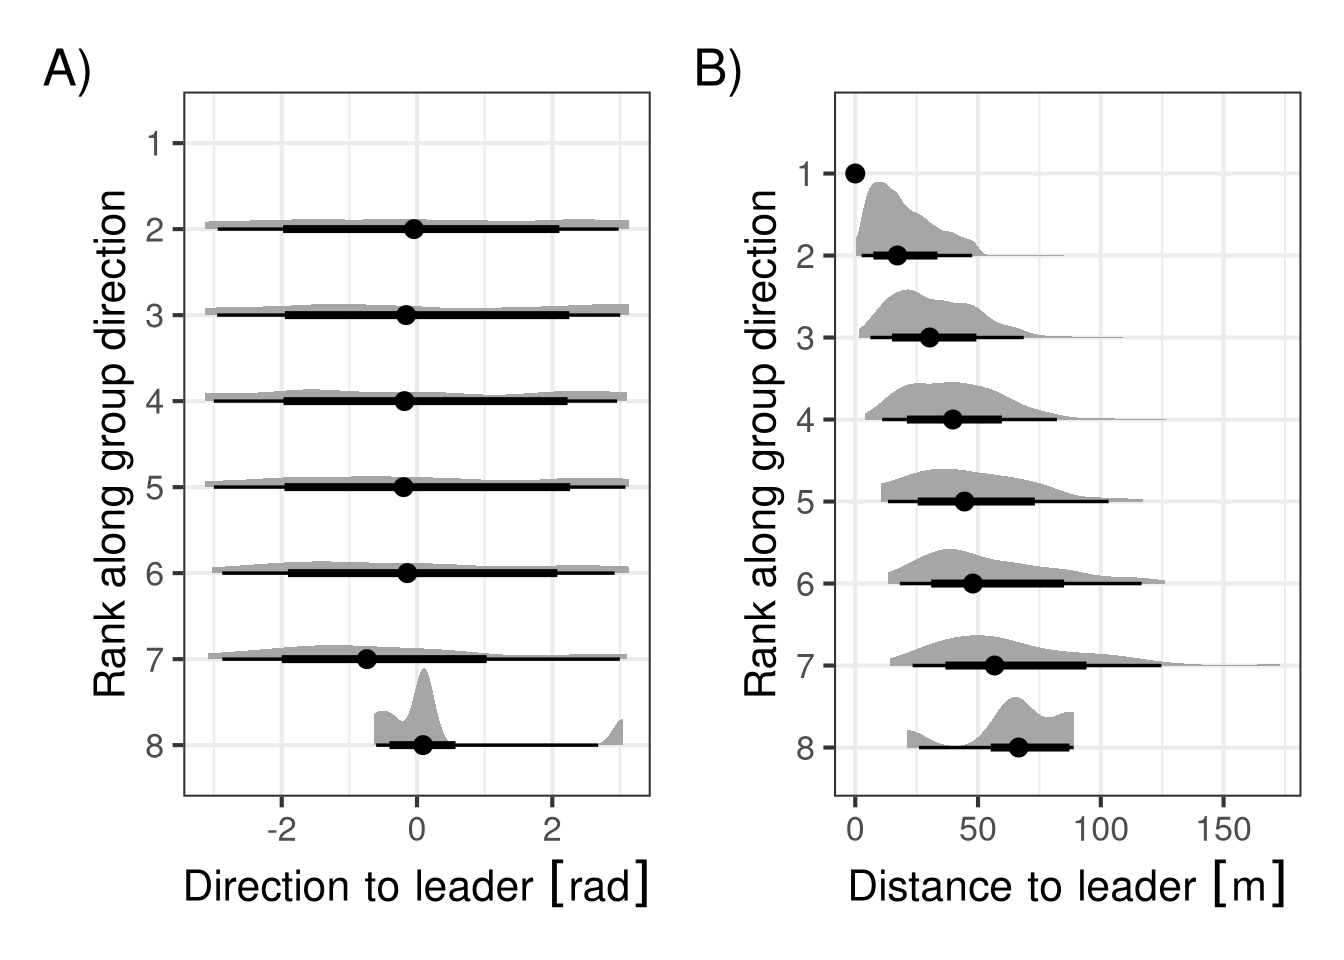

In [ ]:
tar_read(fig_dist_dir_leader)

## Fission fusion

Given the variability in defining fission fusion dynamics in the literature (Supplement B: Scoping Review Results), we developed a flexible function that allows users to both use their system specific definitions and at the same time easily compare to results to other definitions.

Function arguments:

-   `threshold`: spatial distance threshold to establish a fusion event
-   `n_min_length`: the minimum number of successive fixes that are required to establish a fusion event
-   `n_max_missing`: the maximum number of allowable missed observations for either individual in a dyad within a fusion event
-   `allow_split`: if fusion events allow a temporary spatial splitting for one observation without resulting in a fission event

In [ ]:
# Fission fusion events using interindividual distance calculated with edge_dist
fusion_events <- fusion_id(
  interindividual_dist,
  threshold = spatial_threshold, 
  n_min_length = 0, 
  n_max_missing = 0, 
  allow_split = FALSE
)

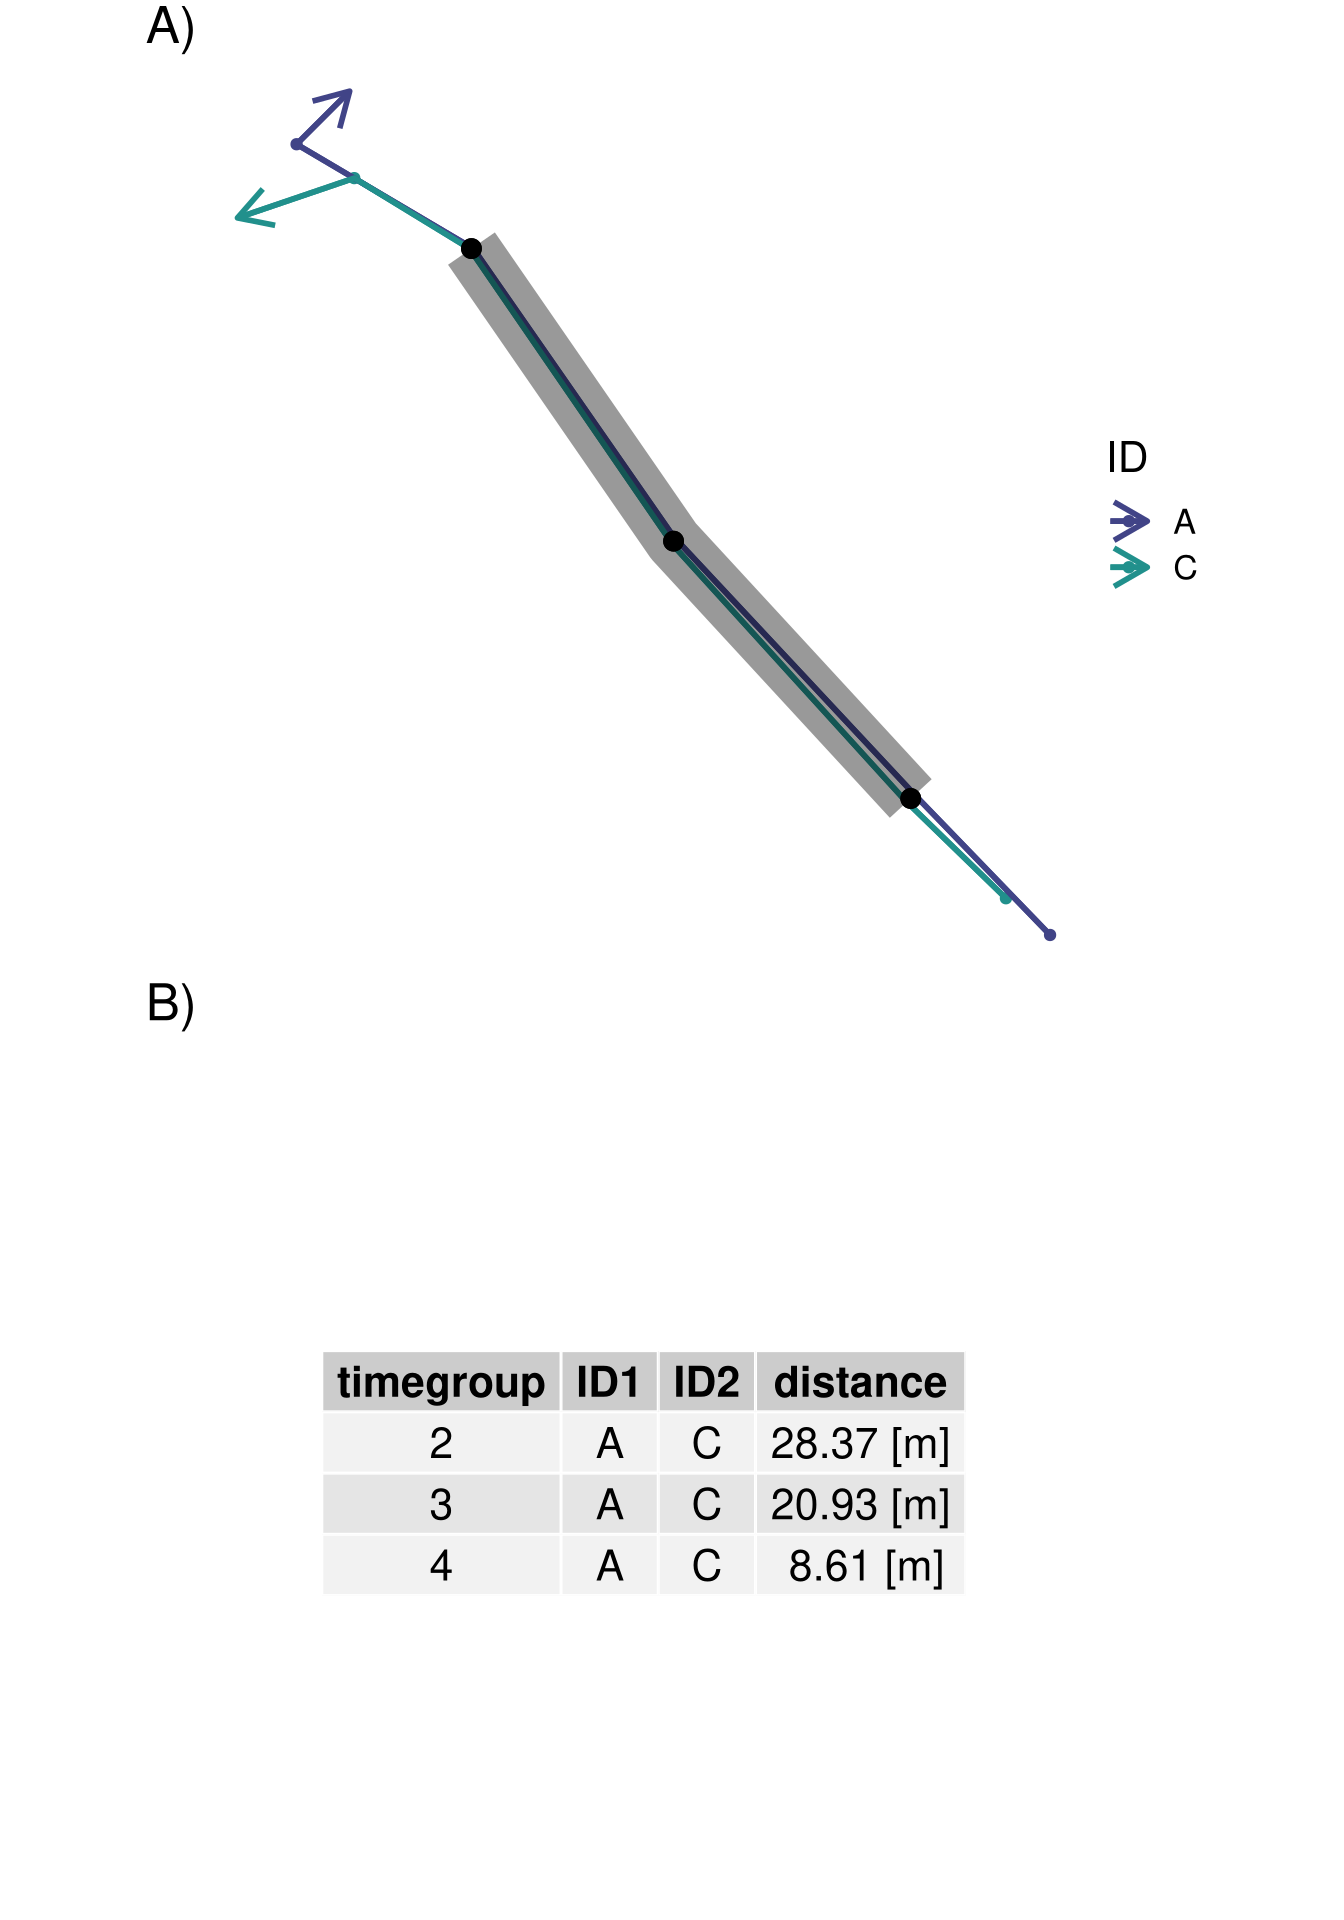

In [ ]:
tar_read(fig_fusion_events)

## Directions

Next, we can use individuals’ directions to explore interindividual direction, directional alignment and group polarization.  
<!-- TODO: describe spatial measures -->

Polarization measures the uniformity of absolute direction in a group of individuals \[@Wang_2022\] on a scale of 0-1 where values near 0 indicate that directions point in different directions and values near 1 indicate that directions point in similar directions.

In [ ]:
direction_polarization(DT)

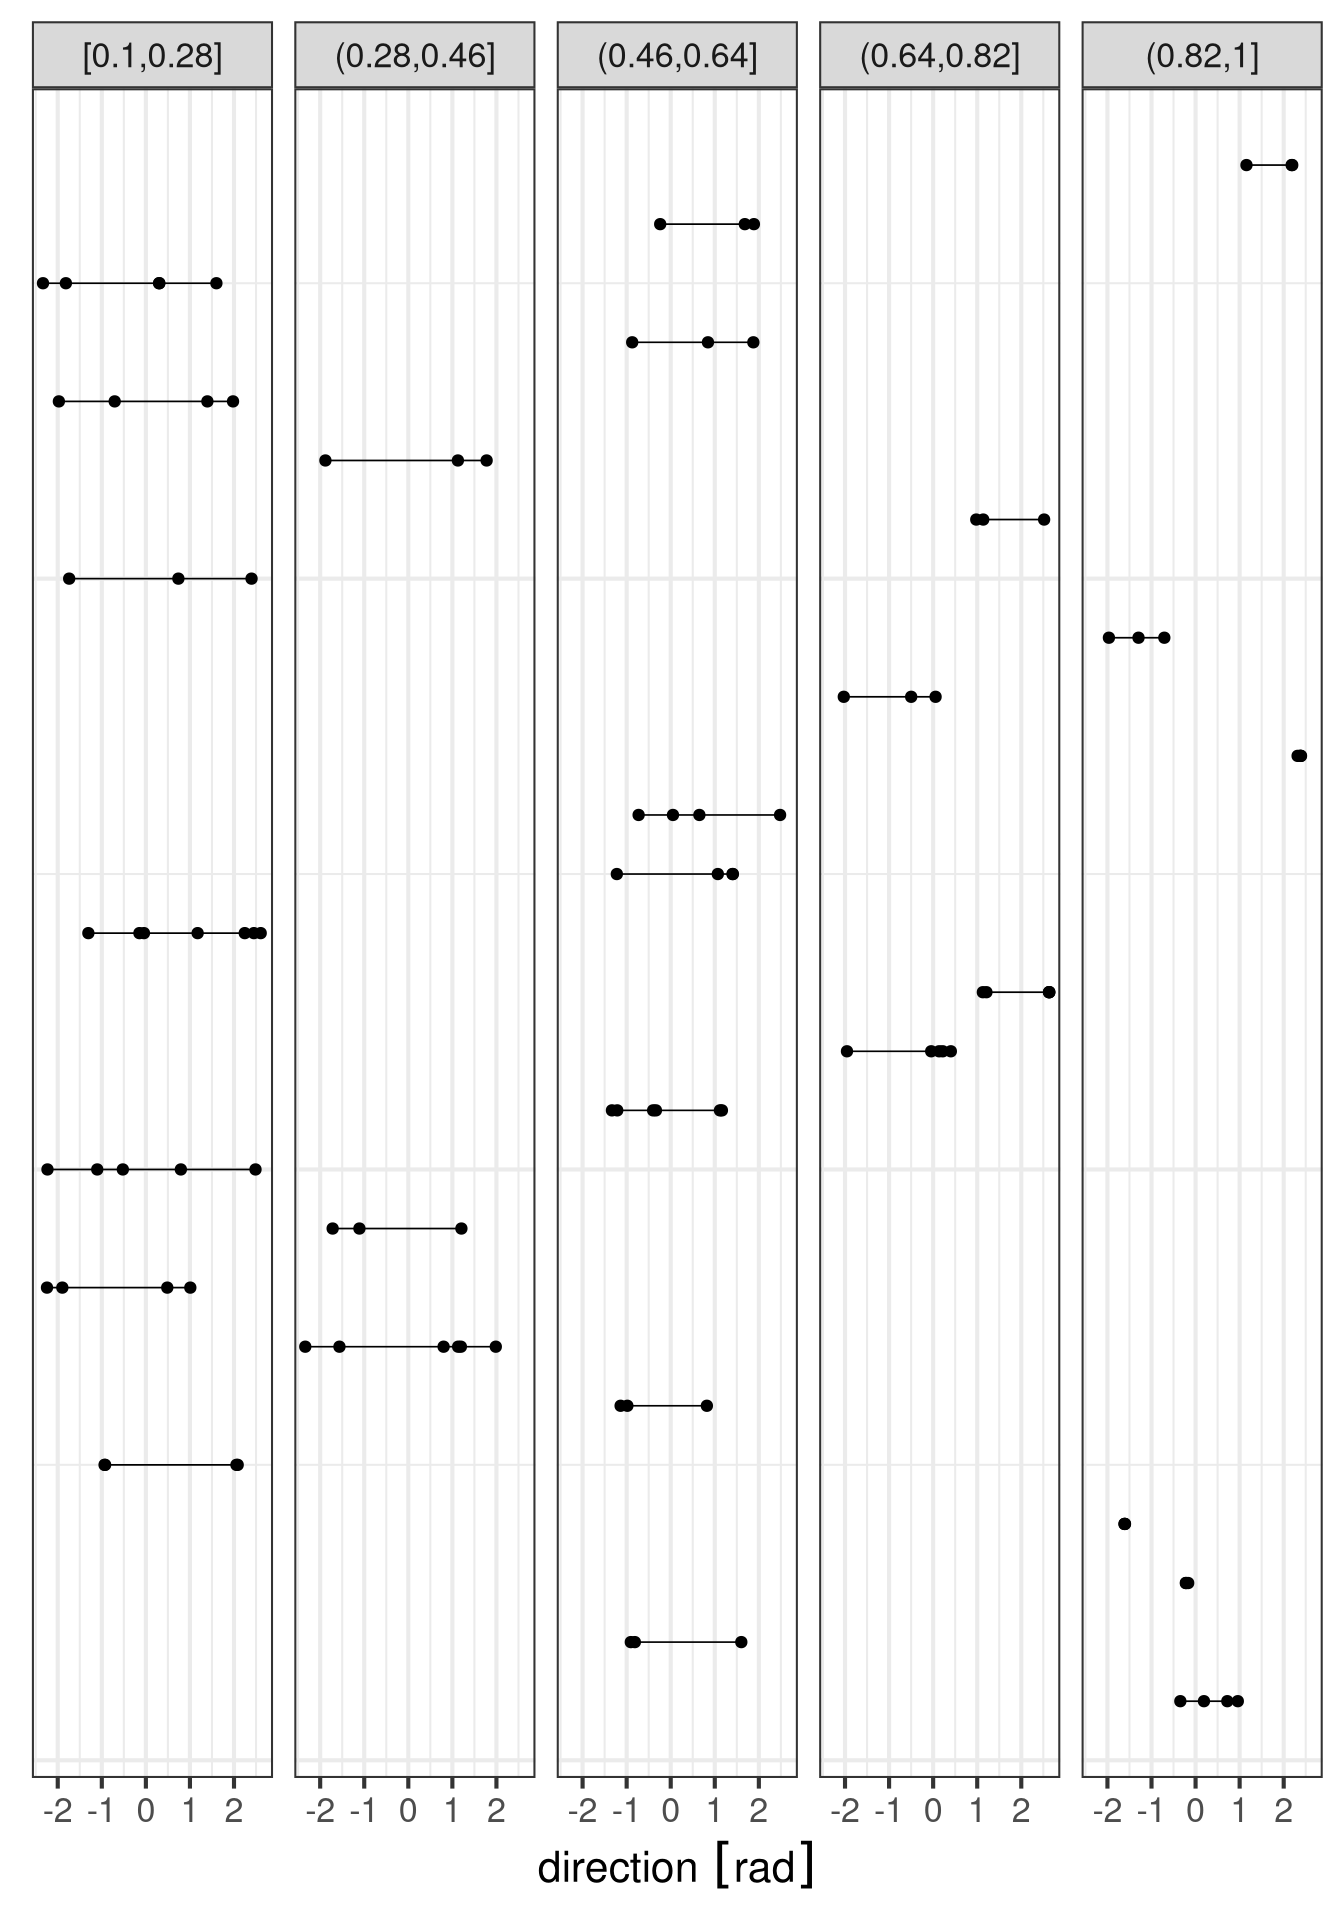

In [ ]:
tar_read(fig_dir_polarization)

Directional alignment is the relative difference between two individuals’ directions. Given the similarity to `edge_dist`, this functionality is provided under a similar name: `edge_alignment`.

In [ ]:
directional_align <- edge_alignment(
  DT = DT,
  id = id,
  signed = FALSE
)

Interindividual direction measures the absolute direction between individuals. <!-- TODO: describe spatial measures -->

In [ ]:
dyad_directions <- edge_direction(
  edges = interindividual_dist,
  DT = DT,
  id = id
)

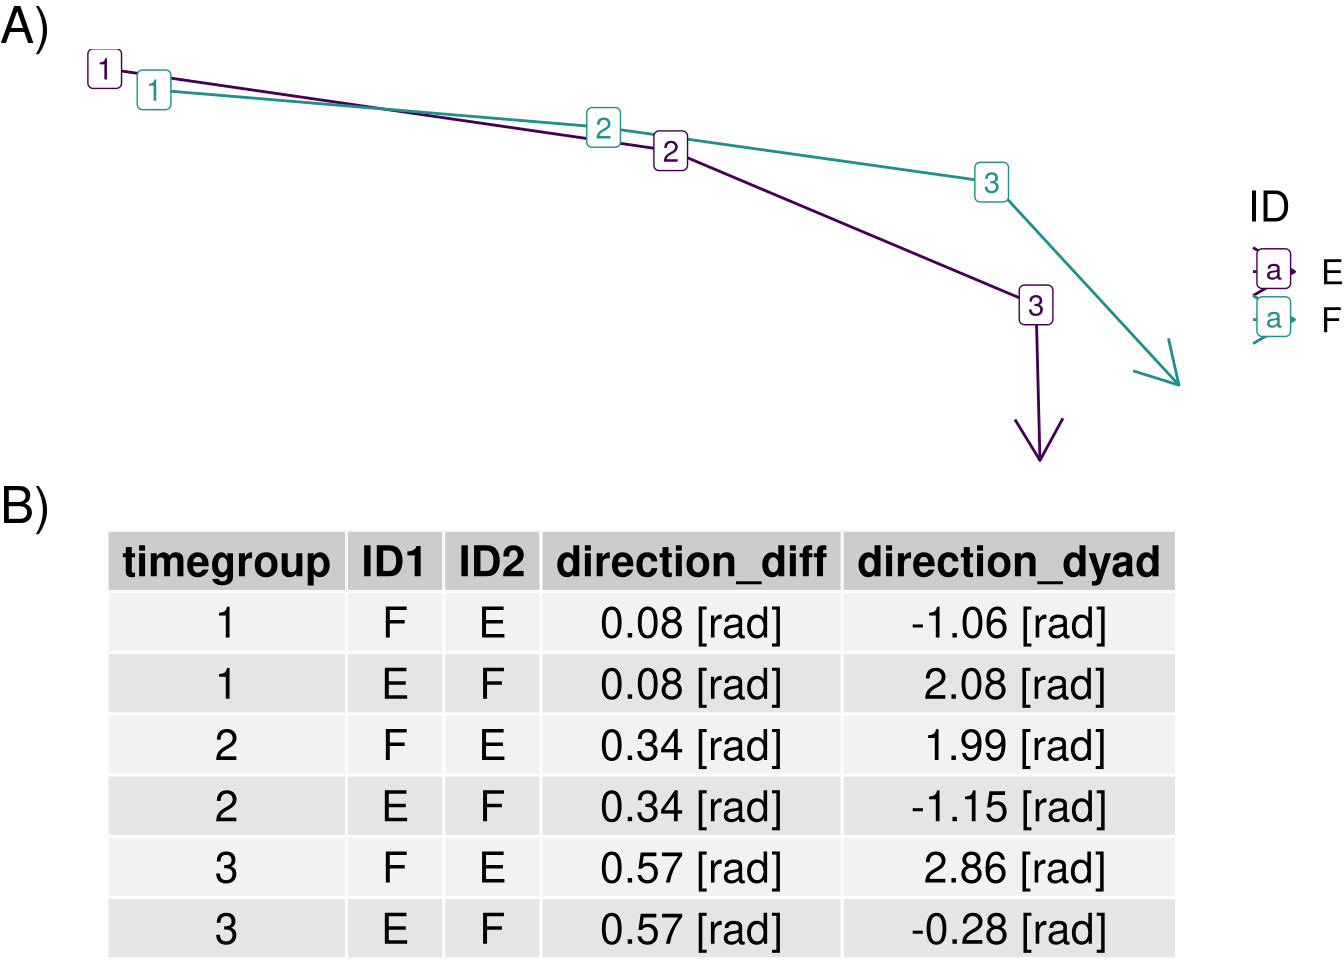

In [ ]:
tar_read(fig_edge_dir_and_align)

## Lagged differences in direction

The directional correlation delay \[@Nagy_2010\] of individuals i, j is given by

$$C_{ij} = [\overrightarrow{v_{i}}(t) * \overrightarrow{j}(t + \tau)]_{t}$$

where

-   $\overrightarrow{v_{i}}(t)$ is the normalized velocity of individual i at time t
-   $\overrightarrow{v_{j}}(t + \tau)$ is the normalized velocity of individual j at time t + $\tau$
-   Note that $C_{ij}(\tau)$ = $C_{ji}(-\tau)$
-   Calculated only where pairs of individuals were less than 100 m apart

The maximum value of the directional correlation function $C_{ij}$ is at $C_{ij}(\tau^{*}_{ij})$ where $\tau^{*}_{ij}$ is the directional correlation delay time. $\tau^{*}_{ij}$ values focus on the relationship in pairs of individuals, ignoring hierarchy changes caused by other individuals.

-   Note that $\tau^{*}_{ij}$ = $-\tau^{*}_{ji}$
-   Negative values indicate that flight directional changes of individual i falls behind that of individual j and therefore j is leading

Hierarchical networks can be generated using $\tau^{*}_{ij}$.

In [ ]:
delay <- edge_delay(
  edges = fusion_events,
  DT = DT,
  window = 3,
  id = id
)

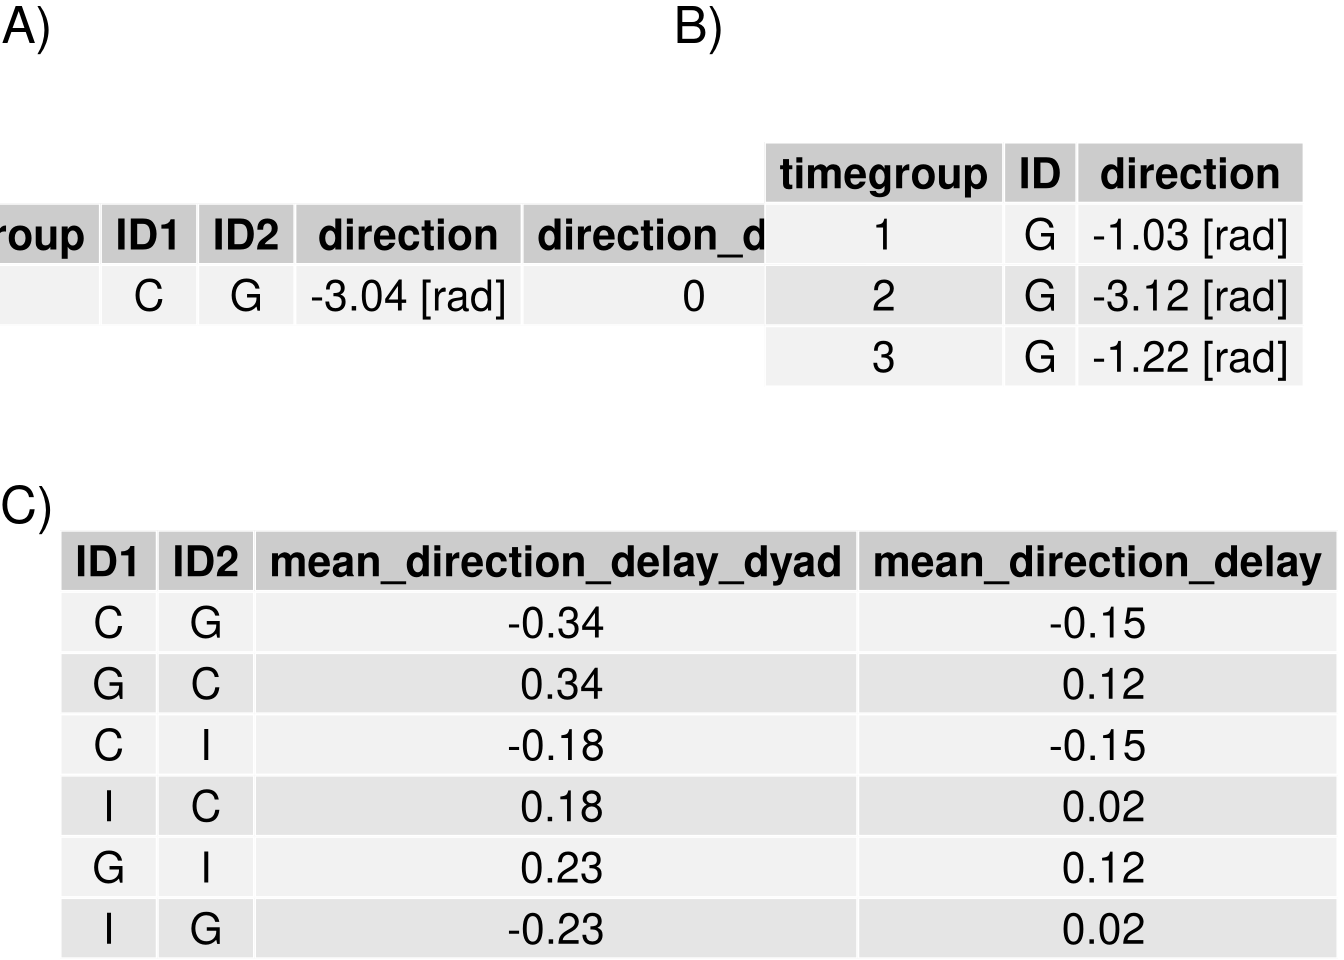

In [ ]:
tar_read(fig_edge_delay)

## Behavioural zones

The behavioural zones metric assigns neighbours to three non-overlapping behavioural zones \[Couzin_2002\]. The “zone of repulsion” is the minimum distance around an individual within which neighbours are expected to move away to avoid collisions. The “zone of orientation” is the next zone around an individual beyond the “zone of repulsion” within which neighbours are expected to orient themselves to the movement of their neighbours. The “zone of attraction” is the farthest zone around an individual within which neighbours are expected to be attracted to the position of the focal individual. Notably, there is a possibly “blind volume” behind the individual representing the limits of their perception.

In [ ]:
zone_thresholds <- c(10, 25, 50)
zone_labels <- c('repulsion', 'orientation', 'attraction')
blind_volume <- 3
delay <- edge_zones(
  interindividual_dist,
  zone_thresholds = zone_thresholds,
  zone_labels = zone_labels,
  blind_volume = blind_volume
)

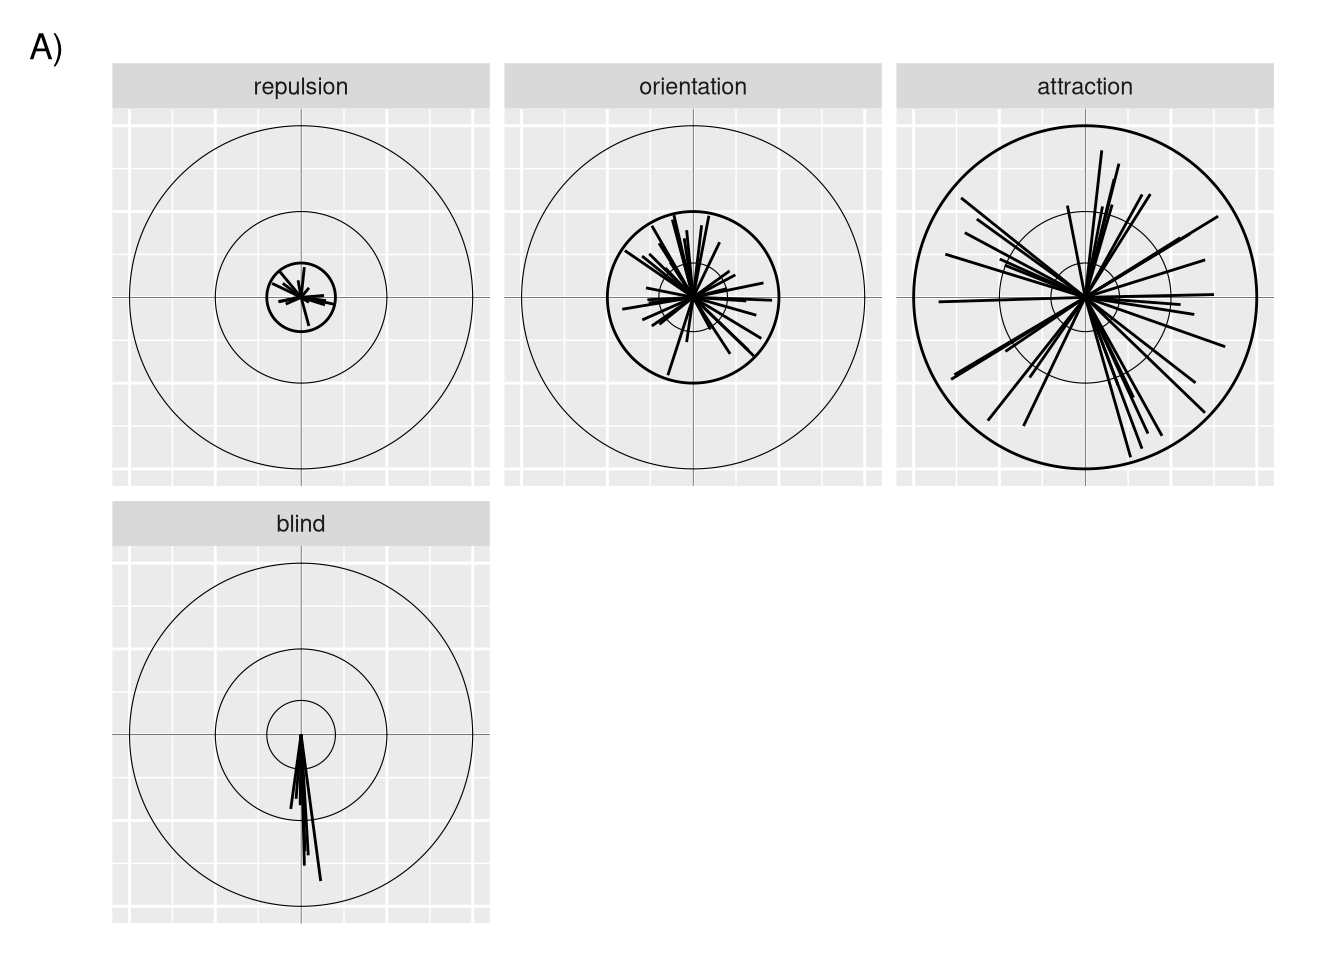

In [ ]:
tar_read(fig_edge_zones)

# Discussion

-   social networks, history of spatsoc
-   high number of studies in review with IID, NND

# Conclusion

# Box 1

Producer-scrounger dynamics describe two strategies of social foragers: “producers” are those who discover patches and “scroungers” are those who join patches discovered by others. This concept can be applied to animal telemetry data by evaluating the position of individuals within groups, the individual’s arrival timing to forage patches and characteristics of forage patches. Individuals balance predation risk and foraging success by adjusting their spatial position within groups (Teichroeb 2015, Hirsch 2019), and the foraging strategy selected by an individual can be influenced by the size of forage patches (Hansen 2016).

Leader-follower patterns in groups of moving animals can be studied both to determine factors that causally influence leadership, and for the influence of leader-follower strategies on foraging success and downstream fitness. Applied to animal telemetry, leadership can be defined simply by identifying the individual at the foremost position along the front-to-back axis of the group’s direction (Quera 2023, Harel 2021). Alternatively, leadership can be identified by calculating the directional correlation delay (Nagy 2010), the temporal delay of shared directional movements between individuals. Leadership in a group of moving animals can inform animal decision making, group coordination, and migratory patterns (Flack 2018, Weesner 2023, Quera 2023, Kano 2021).

Individual traits can influence behaviors related to intragroup dynamics. Dominance is related to foraging success (Caraco 1989, Teichroeb 2015) and choice of foraging strategy (King 2009, Aplin and Morand-Ferron 2017, Lee 2016). Dominant, aggressive, grooming and other interindividual behaviors are typically measured using focal observations. However, some metrics have been developed for remotely estimating dominance behaviors. The directional correlation delay can be used to derive hierarchies of leadership which can be a proxy for dominance relationships in certain species (Flack 2013, Akos 2014). Movement patterns that estimate dominance relationships can be identified from animal telemetry including movement initiations (Amornbunchornvej 2018), approach-avoidance behaviours (Strandburg-Peshkin 2015) and displacement events (Evans 2018).

# References

# Supplement A: Scoping Review Methods

We conducted a scoping review to identify metrics used in ecology studies for measuring dyadic interactions, dominance hierarchies and leadership patterns. We focused on metrics applicable to spatiotemporal data such as GPS telemetry. We used two databases of academic literature: Web of Science and Scopus. We established a test list of nine benchmark papers (Supplement A: Table 1) that were relevant to our objectives and verified that each paper was indexed in our selected databases. We used an iterative search method to fine-tune search terms measuring the total number of papers returned and sensitivity of the search. Sensitivity is defined as the proportion of potentially relevant papers returned from the search estimated using the number benchmark papers returned from the test list (Env Evidence 4.2.7). Search terms were established in four categories: topic, population, method and exclusion (Supplement A: Table 2). Topic included terms associated with dyadic interactions, dominance hierarchies and leadership patterns. Population included terms associated with animals, wildlife and ecology. Method included terms associated with data collection and data types. Finally, a list of exclusion terms were used to remove clearly irrelevant papers. Each category of terms were combined with OR operators and all three categories of terms were combined with AND operators. The set of papers used in further steps was the combination of the last iteration of search terms applied to both of the Web of Science (using the “TS” field) and Scopus (using the “TITLE-ABS-KEY” field) databases. Only articles between 1980-2023 were included using the PY (Web of Science) or PUBYEAR (Scopus) fields. The resulting set of references were imported into Covidence (Covidence systematic review software) for deduplication, title and abstract screening, full text screening, and data extraction.

Before screening, articles were marked as duplicates using Covidence and manual screening. Covidence detected N duplicates based on title, year, volume, and authors, and manual screening identified an additional N duplicates.

Articles were screened out based on the following criteria:

-   Study does not describe dyadic or group metric related to leadership or dominance (eg. @Papageorgiou_2020)
-   Study describes metric that is not applicable to spatiotemporal data (eg. focal observations @Ballesta_2021)
-   Study does not describe metric beyond static interaction (eg. home range or spatial overlap Carter_2013)
-   Study does not describe metric beyond group size (eg. @Delgado_2021)
-   Study full text is not available in English (eg. @Bernard_2002)
-   Study is not a thesis
-   Study is not a book chapter (eg. @Bernstein_2019)

Despite a focus on animal ecology, some studies were discussed movement data more generically or, alternatively, specifically focused on human or robotic movement data (EXAMPLE). These studies were retained when the metrics described were deemed applicable to animal spatiotemporal movement data. Studies using mathematical models or simulations were largely beyond the scope of this review but studies were retained when the parameters used as inputs could be applied to spatial temporal data (eg. @Long_2015). Review studies were retained for building the scope of introduction and discussion but not included in data extraction (eg. @Herbert-Read_2016).

The goals of data extraction were to record the breadth of dyadic social and dominance metrics applicable to spatiotemporal data, and the degree of code availability. General information about each study was recorded including the type of study (empirical, simulation, algorithm, model, or review), study species and study region. Dyadic social metrics for each study were listed including citations and interpretation for each metric used and data input required. Dominance metrics derived from spatiotemporal data were listed including citations and interpretation. Code availability was described including location of code (eg. Zenodo, or GitHub), programming languages and software packages used.

Metrics identified were aggregated using a manual process to identify synonymous terms. This aggregation process was required due to variability in defining metrics during data extraction, as well as differences between authors in describing metrics (eg. distance to group “center”, “centroid”, or “center of mass”). Each study was geocoded using the {tidygeocoder} package \[@Cambon_2021\] and species were parsed using the {rgnparser} package (CITE) which provides the GNparser (CITE) functionality in R. We calculated frequency of data extracted for each categorical field including programming language, software package, analysis code availability, geographic region, study species and metric used. For many fields, authors did not provide sufficient to determine how metrics were calculated, eg. not including the programming language or software package used. In all cases, counts are presented both as an overall frequency including papers with missing fields and subset frequency including only papers that provided sufficient information are retained.

## Form

    Covidence #

    Study ID

    Title

    Reviewer Name

    Study information

    - Type of study
      - Empirical
      - Simulation
      - Algorithm
      - Model
      - Review
      - Other
    - Species
    - Region

    Dyadic social metric

    - Metric used or described
    - Software package(s) used
    - Citation for metric if not introduced in this current paper
    - Interpretation
    - Data input required
    - Definitions of "leader", "initiator", etc

    Dominance

    - Dominance metric
    - Interpretation
    - Citation for dominance metric if not introduced in this paper

    Code availability

    - Analysis code availability
    - Programming language
    - Analysis code link
    - Analysis code availability location
    - Other comments about code availability

    Discussion points, etc

In [ ]:
targets::tar_source('R')
options("tinytable_print_output"="markdown")
tar_read(benchmark_papers) |> tt()

  Citation                                                                                                                                                                                                                                                                                                                 Indexed in WoS
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ ----------------
  Nagy, Máté, Zsuzsa Ákos, Dora Biro, and Tamás Vicsek. 2010. "Hierarchical Group Dynamics in Pigeon Flocks." *Nature* 464 (7290): 890--93. <https://doi.org/10.1038/nature08891>.                                                                                                                                         TRUE
  Strandburg-Peshkin, Ariana, Damien R. Farine, Iain D. Couzin, and Margaret C. Crofoot. 2015. "Shared Decision-Making Drives Collective Movement in Wild Baboons." *Science* 348 (6241): 1358--61.                                                                                                                        TRUE
  Merkle, J.A., M. Sigaud, and D. Fortin. 2015. "To Follow or Not? How Animals in Fusion--Fission Societies Handle Conflicting Information during Group Decision-Making." *Ecology Letters* 18 (8): 799--806.                                                                                                              TRUE
  Andersson, Mattias, Joachim Gudmundsson, Patrick Laube, and Thomas Wolle. 2007. "Reporting Leadership Patterns among Trajectories." In *Proceedings of the 2007 ACM Symposium on Applied Computing*, 3--7. SAC '07. New York, NY, USA: Association for Computing Machinery. <https://doi.org/10.1145/1244002.1244004>.   TRUE
  Flack, Andrea, Máté Nagy, Wolfgang Fiedler, Iain D. Couzin, and Martin Wikelski. 2018. "From Local Collective Behavior to Global Migratory Patterns in White Storks." *Science* 360 (6391): 911--14.                                                                                                                     TRUE
  Bracken, A.M., C. Christensen, M.J. O'Riain, I. Fürtbauer, and A.J. King. 2022. "Flexible Group Cohesion and Coordination, but Robust Leader-Follower Roles, in a Wild Social Primate Using Urban Space." *Proc. R. Soc. B Biol. Sci.* 289 (1967). <https://doi.org/10.1098/rspb.2021.2141>.                             TRUE
  Long, Jed A., Trisalyn A. Nelson, Stephen L. Webb, and Kenneth L. Gee. 2014. "A Critical Examination of Indices of Dynamic Interaction for Wildlife Telemetry Studies." *Journal of Animal Ecology* 83 (5): 1216--33. <https://doi.org/10.1111/1365-2656.12198>.                                                         TRUE
  Dodge, Somayeh, Robert Weibel, and Anna-Katharina Lautenschütz. 2008. "Towards a Taxonomy of Movement Patterns." *Information Visualization* 7 (3--4): 240--52. <https://doi.org/10.1057/PALGRAVE.IVS.9500182>.                                                                                                          TRUE
  Laube, Patrick, Stephan Imfeld, and Robert Weibel. 2005. "Discovering Relative Motion Patterns in Groups of Moving Point Objects." *International Journal of Geographical Information Science* 19 (6): 639--68. <https://doi.org/10.1080/13658810500105572>.                                                             TRUE

  : Table S-A.1 Benchmark papers


In [ ]:
options("tinytable_print_output" = NULL)
tar_read(search_strings) |> tt()

Source,String
Web of Science,"TS=(""dominance hierarch*"" OR ""leadership"" OR ""dominance"" OR ""collective move*"" OR ""fusion-fission"" OR ""fission-fusion"" OR (""fission*"" AND ""fusion*"") OR (""producer*"" AND ""scrounger"") OR ""producer-scrounger"" OR ""leader-follower"" OR ""leader follower"" OR (""leader*"" AND ""follower*"") OR (""finder*"" AND ""joiner*"") OR ""group cohesion"" OR ""dynamic interaction"" OR ""leadership pattern*"" OR ""collective behav*"" OR ""spatiotemporal group*"" OR ""relative motion"" OR ""group dynamics"") AND TS=(""ecolog*"" OR ""animal*"" OR ""wildlife"") AND TS=((""spatial*"" AND ""network*"") OR ""track*"" OR ""gps"" OR ""telemetry"" OR ""PIT"" OR ""video"" OR ""RFID"" OR ""biotelem*"" OR ""spatiotemporal"" OR ""spatio-temporal"" OR ""GPS"" OR ""movement pattern*"") NOT TS=(""human group*"" OR ""robot*"" OR ""genetic algorithm"" OR ""cell movement"" OR ""cellular"" OR ""sport*"" OR ""team sport*"" OR ""task force"" OR ""food web*"" OR ""host plant*"" OR ""fossil"" OR ""urbanism"" OR ""psychiatry"" OR ""bile"") AND PY=(1980-2023)"
Scopus,"TITLE-ABS-KEY (""dominance hierarch*"" OR ""leadership"" OR ""dominance"" OR ""collective move*"" OR ""fusion-fission"" OR ""fission-fusion"" OR (""fission*"" AND ""fusion*"") OR (""producer*"" AND ""scrounger"") OR ""producer-scrounger"" OR ""leader-follower"" OR ""leader follower"" OR (""leader*"" AND ""follower*"") OR (""finder*"" AND ""joiner*"") OR ""group cohesion"" OR ""dynamic interaction"" OR ""leadership pattern*"" OR ""collective behav*"" OR ""spatiotemporal group*"" OR ""relative motion"" OR ""group dynamics"") AND TITLE-ABS-KEY (""ecolog*"" OR ""animal*"" OR ""wildlife"") AND TITLE-ABS-KEY ((""spatial*"" AND ""network*"") OR ""track*"" OR ""gps"" OR ""telemetry"" OR ""PIT"" OR ""video"" OR ""RFID"" OR ""biotelem*"" OR ""spatiotemporal"" OR ""spatio-temporal"" OR ""GPS"" OR ""movement pattern*"") AND NOT TITLE-ABS-KEY (""human group*"" OR ""robot*"" OR ""genetic algorithm"" OR ""cell movement"" OR ""cellular"" OR ""sport*"" OR ""team sport*"" OR ""task force"" OR ""food web*"" OR ""host plant*"" OR ""fossil"" OR ""urbanism"" OR ""psychiatry"" OR ""bile"") AND PUBYEAR > 1980"


# Supplement B: Scoping Review Results

In [ ]:
targets::tar_source('R')

tar_load(review)
tar_load(geocoded)
tar_load(taxized)
tar_load(software_meta)

tar_load(counted)
count_code_avail <- counted$count_code_avail
count_prog_lang <- counted$count_prog_lang
count_software <- counted$count_software
count_metric <- counted$count_metric
count_dom_metric <- counted$count_dom_metric

## Results

### PRISMA

    3870 references imported for screening as 3870 studies
        128 duplicates identified manually
        799 duplicates identified by Covidence
    2943 studies screened against title and abstract
        2527 studies excluded
    416 studies assessed for full-text eligibility
        275 studies excluded
            184  Does not discuss dyadic measure
            86  Metric not applicable to spatiotemporal data
            2  Book chapter
            2  Full text not in English
            1  Thesis
        0 studies ongoing
        0 studies awaiting classification
    141 studies included

### Code availability

In [ ]:
count_code_avail[, .N, analysis_code_availability][order(-N), .(
  `Code availability` = analysis_code_availability,
  N = paste_n_percent(N)
)] |> tt()

Code availability,N
No,114 (81%)
Yes,26 (19%)


### Programming language / GUI program

In [ ]:
list_prog <- count_prog_lang[, uniqueN(covidence_number), .(prog = !is.na(programming_language))]
unique_prog_lang <- count_prog_lang[, uniqueN(programming_language), covidence_number]

Out of 141 articles, 52 did not list a programming language or GUI program. Of the 89 that did, 21 articles listed more than one programming language or GUI program, therefore the total count below will be greater than the number of articles.

In [ ]:
count_prog_lang[, .N, programming_language][order(-N), .(
  `Programming language` = programming_language,
  N = paste_n_percent(N)
)] |> tt()

Programming language,N
R,62 (36.26%)
NA,52 (30.41%)
MATLAB,15 (8.77%)
Python,6 (3.51%)
CUDA,4 (2.34%)
Ucinet,3 (1.75%)
Perl,3 (1.75%)
C++,3 (1.75%)
NetLogo,2 (1.17%)
SPSS,2 (1.17%)


### Software packages

Out of 140 articles, 112 did not list a software package. Of the 28 that did, 14 articles listed more than one software package , therefore the total count below will be greater than the number of articles.

In [ ]:
count_software[, .N, software_package_s_used][order(-N), .(
  `Software package used` = software_package_s_used,
  N = paste_n_percent(N)
)] |> tt()

Software package used,N
NA,112 (66.67%)
wildlifeDI,9 (5.36%)
geosphere,3 (1.79%)
adehabitat,2 (1.19%)
moveVis,2 (1.19%)
ctmm,2 (1.19%)
CircStats,2 (1.19%)
corrMove,2 (1.19%)
adehabitatHR,2 (1.19%)
numpy,2 (1.19%)


#### Software packages metadata

In [ ]:
software_meta |> 
  tt()

package,N,description,on_CRAN,archive_date,months_since_updated,metrics
wildlifeDI,9,"dyadic interaction metrics, contact analysis",TRUE,NA,3,Ca; Cr; DI; Don; HAI; IAB; Lixn; Prox
swaRm,1,processing individual and collective movement data,TRUE,NA,3,angular acceleration; ang speed; centroid; convex hull; dist to centroid; heading; linear acc; speed; dist; NN; NN dist; NSD; dist matrix; polarization order; sphericity; stretch
corrMove,2,correlated movements between individuals,FALSE,NA,84,diffusive movement correlation; drift movement correlation; overall component movement correlation
adehabitatLT,1,analysis of animal movements,TRUE,NA,10,NA
adehabitatHR,2,home range estimation,TRUE,NA,10,NA
adehabitat,2,analysis of habitat selection,FALSE,2018-04-10,84,NA
moveVis,2,animating movement trajectories,FALSE,2023-07-11,24,NA
sf,0,spatial data,TRUE,NA,0,NA
ctmm,2,continuous time movement modeling,TRUE,NA,0,NA
geosphere,2,spherical trigonometry,TRUE,NA,6,NA


### Temporal

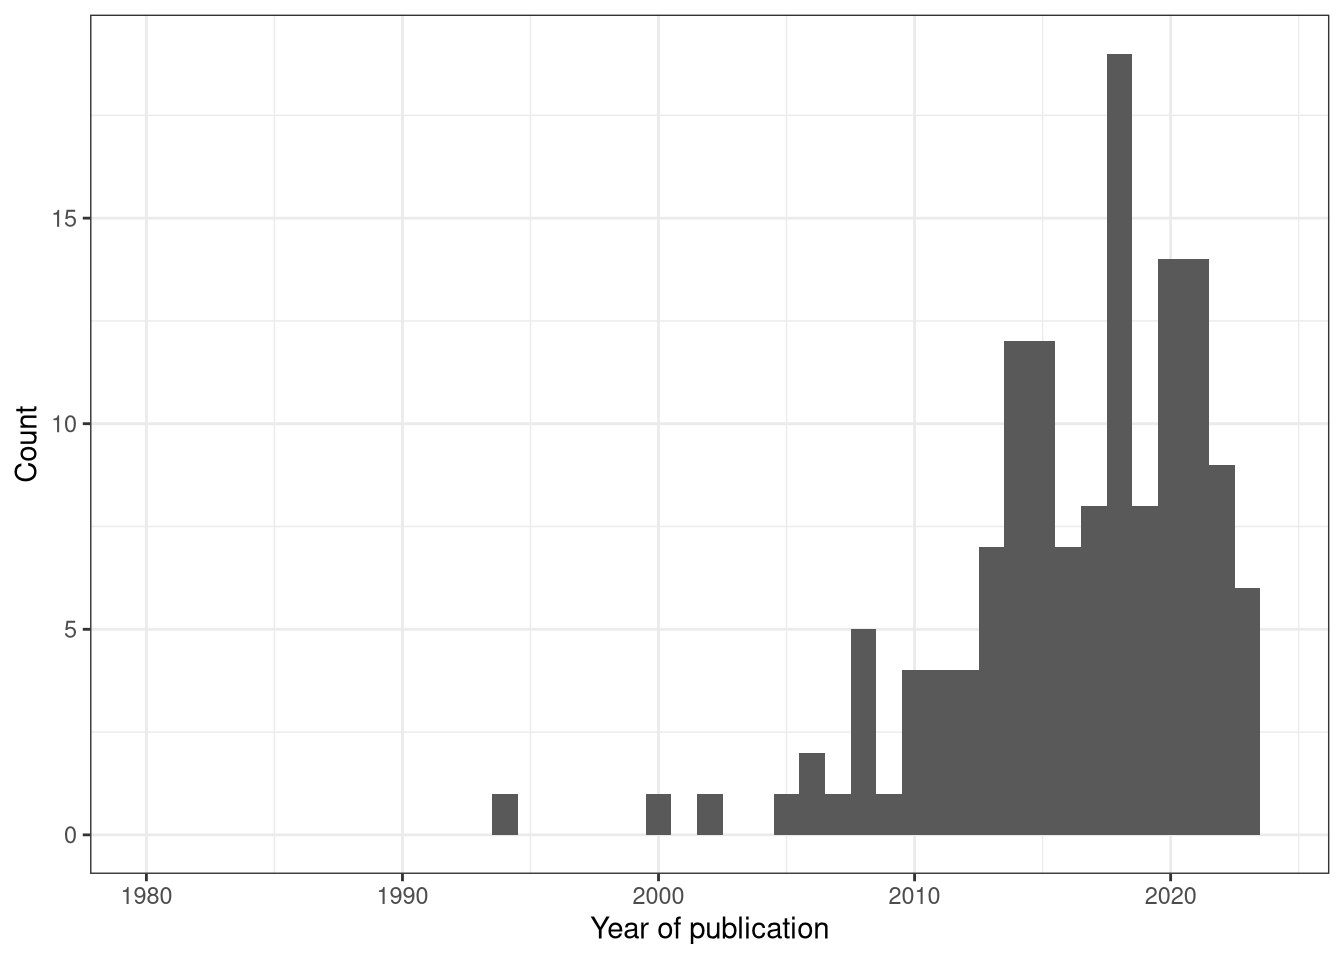

In [ ]:
ggplot(review) + 
  geom_histogram(aes(yr), binwidth = 1) + 
  labs(x = 'Year of publication', y = 'Count') + 
  coord_cartesian(xlim = c(1980, 2024)) +
  theme_bw()

### Geographic

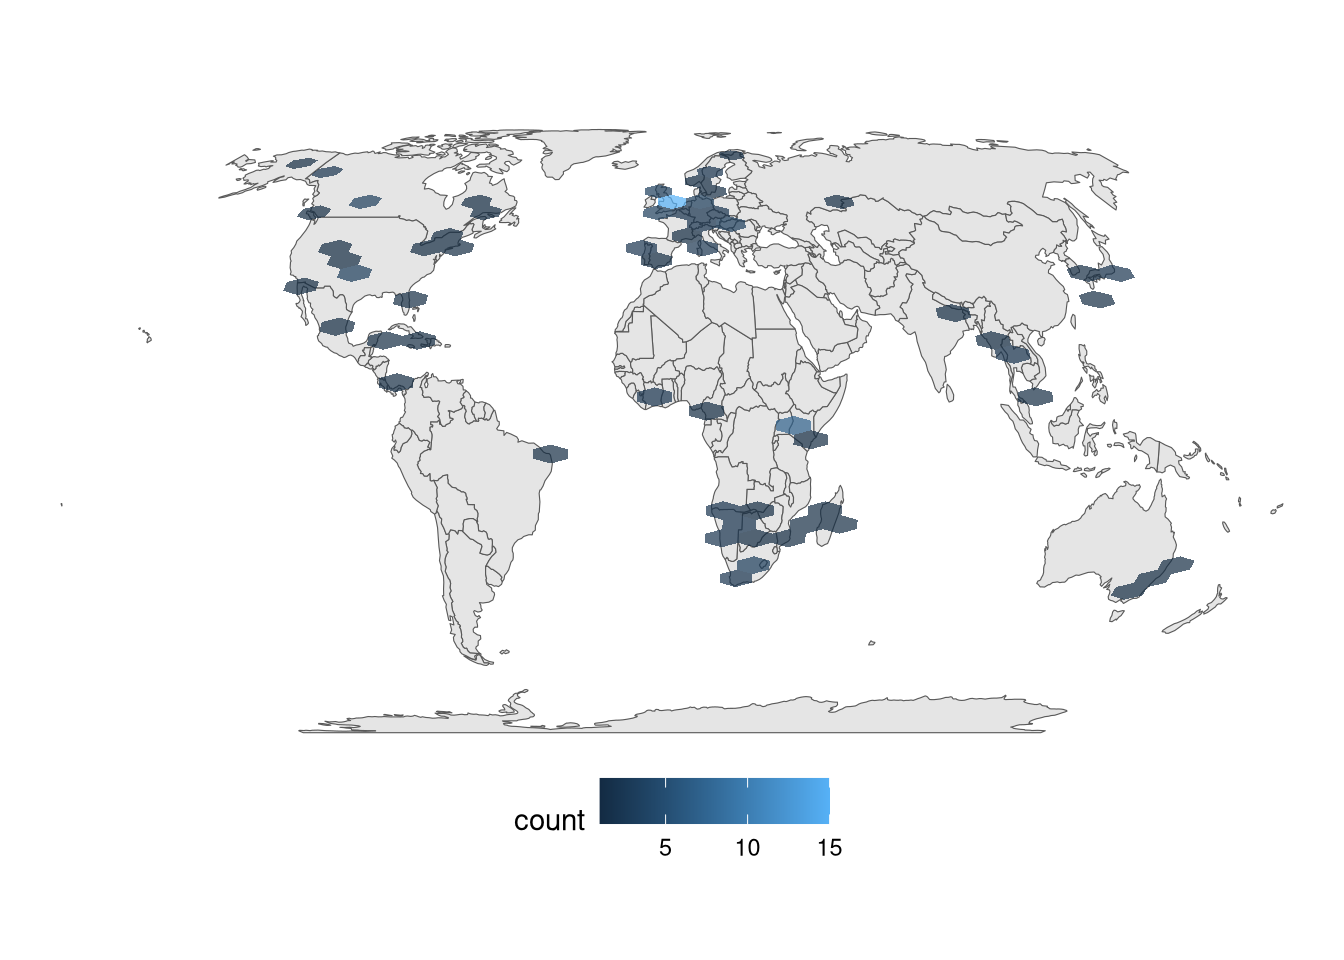

In [ ]:
countries <- ne_countries()

crs <- 8857

ggplot() + 
  geom_sf(data = countries) + 
  geom_hex(aes(long, lat), alpha = 0.7, data = geocoded[!is.na(long)]) + 
  coord_sf(crs = crs, default_crs = 4326) + 
  theme_void() + 
  theme(legend.position = 'bottom')

### Species

In [ ]:
taxized[, .N, parsed_species][order(-N), .(
  Species = parsed_species,
  N = paste_n_percent(N)
)] |> tt() |> style_tt(j = "Species", italic = TRUE)

Species,N
Columba livia,9 (7.09%)
Danio rerio,6 (4.72%)
Rangifer tarandus,6 (4.72%)
Gasterosteus aculeatus,5 (3.94%)
Papio anubis,5 (3.94%)
Poecilia reticulata,5 (3.94%)
Macaca fuscata,4 (3.15%)
Ovis aries,4 (3.15%)
Bos taurus,3 (2.36%)
Ateles geoffroy,3 (2.36%)


### Metrics

#### Definitions of spatiotemporal groups

In [ ]:
review[definition_category == 'group', .(study_id, definition)] |>
  tt()

study_id,definition
Quaglietta 2014,interaction if within 100 m and 1 hour
Mielke 2020,group defined as all individuals within visual contact of focal individual
Leighty 2008,proximity defined as 8 m; approach/avoidance after event defined as changes in interindividual distance after an event
Hansen 2015,fish considered isolated if not within three body lengths of any other fish; group defined by within three body lengths
Bista 2022,"temporal threshold 2 hour, distance threshold 100 m"
Pinacho-Guendulain 2017,group using 30 m chain rule
Lemasson 2014,group when within 5 body lengths
Inoue 2019,proximity defined as two body lengths away


#### Count of metrics measuring intragroup dynamics

In [ ]:
count_metric[, .N, metric_agg][order(-N), .(
  `Metric` = metric_agg,
  N = paste_n_percent(N)
)] |> tt()

Metric,N
interindividual distance,61 (14.66%)
nearest neighbour distance,19 (4.57%)
directional correlation delay,18 (4.33%)
speed,17 (4.09%)
position within group,16 (3.85%)
direction,15 (3.61%)
fission fusion,15 (3.61%)
zones,15 (3.61%)
distance to group centroid,14 (3.37%)
directional alignment,9 (2.16%)


### Definitions of leadership

In [ ]:
review[definition_category == 'leadership', .(study_id, definition)] |>
  tt()

study_id,definition
Rahman 2020,leadership as tendency to be at the front of the group
Quera 2023,"following Krause et al. (2000) and Collignon et al. (2019), the authors define a motion leader as an individual who initiates movement towards a certain direction and is followed by other group members"
Andrienko 2013,leader is an object that moves in front of others; trend setter is an object whose movements are copied by others
Amornbunchornvej 2018,following relation is where two individuals perform the same sequence of actions with some fixed delay; initiator is individual who first performs a sequence of actions and all other individuals follow
Kano 2021,leader from directional correlation delay
Pettit 2013,leadership based on directional correlation delay; leadership also based on tendency to use route taken on solo flight
Pérez-Barbería 2018,leadership is ranked position along front-back axis
Laube 2005,leadership extends flock with constance over previous time steps
Milner 2021,leader is animal that is dominant to at least one and subordinate to none
Strandburg-Peshkin 2018,an individual leads if it has repeated influence either directly or hierarchically on the behaviour of others


### Definitions of fission fusion

In [ ]:
review[definition_category == 'fission fusion', .(study_id, definition)] |>
  tt()

study_id,definition
Baden 2016,NA
Aguilar-Melo 2018,fission when gte 1 were not observed with a group for 2 consecutive scans; fusion when gte 1 who were previously not observed with group are observed with group for 2 consecutive scans
Barocas 2016,fission and fusion defined as joining and leaving group in subsequent observations
Haydon 2008,fusion where solitary to grouped and fission where grouped to solitary
Fortin 2009,group/fusion when within 100 m; fission when two or more consecutive locations separated by > 100 m
Body 2015,fusion gte 2 groups merging into one; fission one group splitting into gte 2
DellaLibera 2023,"define a fission and fusion event if one or more individuals left or joined the group, respectively. in the rare cases of missing data, missing individuals are not considered as having changed group membership, and individual ‘disappearances’ and ‘reappearances’ in the dataset are not considered as fission–fusion events"
Wielgus 2020,group where simultaneously within 1 km or >= 1 km for <= 2 hr; fusion where together then different by one time step; fission reverse
Nishikawa 2014,converged when IID less than 20 m; separated when IID greater than 20 m; converged and separated synonymous with fission fusion
Krueger 2014,NA


#### Count of methods measuring dominance

In [ ]:
count_dom_metric[, .N, dominance_metric_agg][order(-N), .(
  `Dominance metric` = dominance_metric_agg,
  N = paste_n_percent(N)
)] |> tt()

Dominance metric,N
NA,112 (77.78%)
focal observations,14 (9.72%)
direction correlation delay,5 (3.47%)
fleeing events,2 (1.39%)
survey,2 (1.39%)
approach-avoidance events,2 (1.39%)
egalitarian leadership index,1 (0.69%)
movement initiations,1 (0.69%)
proportion of paired flights led,1 (0.69%)
spatially constrained trend-setter,1 (0.69%)


# Supplement C: Selected Metrics

In [ ]:
targets::tar_source('R')
tar_load(taxized)
tar_load(geocoded)
tar_load(review)
tar_load(counted)
count_code_avail <- counted$count_code_avail
count_prog_lang <- counted$count_prog_lang
count_software <- counted$count_software
count_metric <- counted$count_metric

## Directional correlation delay

In [ ]:
dirr_del <- count_metric[metric_agg == 'directional correlation delay']

Our review found 17 studies that used the directional correlation delay metric, across 12 study species. Only 1 study had code available using a combination of MATLAB (closed source), CUDA (closed source), and Python (open source). To our knowledge, there are no R packages that provide this metric.

## Position within group, rank position within group, time spent leading group, distance and direction to leader

In [ ]:
pos_wi <- count_metric[metric_agg %in% c('position within group', 
                                 'rank position within group',
                                 'time spent leading group',
                                 'distance to leader',
                                 'direction to leader')]

Our review found 20 studies that used the position within group, rank position within group, time spent leading group metrics, distance to leader, or direction to leader metrics across 16 study species. Only 2 study had code available. To our knowledge, there are no R packages that provide these metrics.

## Distance, direction and rank distance to group centroid

In [ ]:
to_grp_cent <- count_metric[metric_agg %in% c('direction to group centroid', 
                                      'distance to group centroid',
                                      'rank distance to group centroid',
                                      'group centroid')]

Our review found 21 studies that used the group centroid, distance to group centroid, direction to group centroid, or rank distance to group centroid metrics, across 14 study species. 4 studies had code available. The {swaRm} package provides functionality to calculate the group centroid and the distance to the group centroid. To our knowledge, there are no R packages that provided the direction and rank distance to group centroid metrics.

## Polarization, directional alignment and interindividual direction

In [ ]:
align <- count_metric[metric_agg %in% c('polarization', 
                                'directional alignment',
                                'interindividual direction',
                                'nearest neighbour direction')]

Our review found 20 studies that used the polarization, directional alignment or interindividual direction metrics, across 11 study species. 4 studies had code available. The {swaRm} package provides functionality to calculate the polarization order parameter, as well as the {CircStats} package. To our knowledge, there are no R packages that provide the directional alignment or interindividual direction metrics.

## Behavioural zones

In [ ]:
zone <- count_metric[metric_agg %in% c('zones')]

Our review found 13 studies that used the behavioural zones metric, across 9 study species. 4 studies had code available. To our knowledge, there are no R packages that provided the behavioural zones metric.

## Not selected

-   {wildlifeDI} (DI, Don, Prox, Lixn, Cs, DI in direction, DI in displacement, HAI, IAB, Cr, Ca)
-   {corrMove} (diffusive movement correlation, drift movement correlation, overall component movement correlation)
-   metrics relating to posture
-   static interaction eg. home range overlap
-   voronoi
-   HMM
-   change point detection
-   mFLICA
    -   available
-   FLOCK
-   LPD
-   Granger causality
-   Influence maximization